# Extension 3: Medical Image Classification using HAM10000 dataset

In [ ]:
"""
Block 1: Configuration (Extension 3c- Model : Swin)
Defines training setup, output directory, and augmentation toggles.
"""
import os

# --- 1. Execution Mode ---
TEST_MODE = False

# --- 2. Dataset & Model ---
DATA_SET = "image_folder"
TRAIN_DATA_PATH = "./data/HAM10000_split/train"
VAL_DATA_PATH = "./data/HAM10000_split/val"
NB_CLASSES = 7 #HAM10000 has 7 categories/classes as compared to CIFAR which has 100 
INPUT_SIZE = 224 #224 resolution
MODEL_NAME = "swin_tiny_patch4_window7_224"

# --- 3. Hyperparameters ---
BATCH_SIZE = 64 #64 instead of 128
EPOCHS = 50 #50 epoch instead of 100
WARMUP_EPOCHS = 20
OPT = "adamw"
LR = 4e-3
WEIGHT_DECAY = 0.05
DROP_PATH = 0.1

# --- 4. Augmentation Control Panel ---
MIXUP = 0.0
CUTMIX = 0.0
SMOOTHING = 0.0
COLOR_JITTER = 0.0 
REPROB = 0.0       
AA_POLICY = ""  

# --- 5. Model EMA ---
MODEL_EMA = "false"
MODEL_EMA_EVAL = "false"

# --- 6. Output ---
CHECKPOINT_DIR = "./output/ext3_HAM10000_swin"
REPO_NAME = "dsa5106-convnext-extension"

In [2]:
"""
Block 2: Hardware Check
Verify PyTorch and GPU availability.
"""

import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.9.0+cu126
CUDA available: True
GPU: Tesla T4


In [3]:
"""
Block 3: Clone official ConvNeXt repository and apply compatibility patches.
"""

import os
import shutil
import fileinput

os.chdir("/kaggle/working")

repo_name = "ConvNeXt"

if os.path.exists(repo_name):
    shutil.rmtree(repo_name)

!git clone https://github.com/facebookresearch/ConvNeXt.git -q
os.chdir(repo_name)

print("Working directory:", os.getcwd())

!pip install -q uv
!uv pip install --system timm==0.6.13 tensorboardX six

# Patch NovoGrad dependency
optim_file = "optim_factory.py"
if os.path.exists(optim_file):
    for line in fileinput.input(optim_file, inplace=True):
        if "from timm.optim.novograd import NovoGrad" in line:
            print("# " + line, end="")
        elif "NovoGrad(" in line:
            print(line.replace("NovoGrad(", "torch.optim.AdamW("), end="")
        else:
            print(line, end="")
    print("Patched optim_factory.py")

# Patch deprecated torch._six import
utils_file = "utils.py"
if os.path.exists(utils_file):
    for line in fileinput.input(utils_file, inplace=True):
        if "from torch._six import inf" in line:
            print("from math import inf")
        else:
            print(line, end="")
    print("Patched utils.py")

# Ensure wrapper functions absorb pretrained_cfg from timm
convnext_file = "models/convnext.py"

if os.path.exists(convnext_file):
    with open(convnext_file, "r") as f:
        lines = f.readlines()

    updated_lines = []
    for line in lines:
        # Patch wrapper function convnext_tiny
        if line.strip().startswith("def convnext_tiny("):
            updated_lines.append(line)
            updated_lines.append("    kwargs.pop('pretrained_cfg', None)\n")
            continue

        updated_lines.append(line)

    with open(convnext_file, "w") as f:
        f.writelines(updated_lines)

    print("Patched models/convnext.py (wrapper absorbs pretrained_cfg)")

# Patch main.py so ConvNeXt-only arguments are removed for other models
main_file = "main.py"

if os.path.exists(main_file):
    for line in fileinput.input(main_file, inplace=True):

        if "layer_scale_init_value=args.layer_scale_init_value" in line:
            continue

        if "head_init_scale=args.head_init_scale" in line:
            continue

        print(line, end="")

    print("Patched main.py (removed ConvNeXt-only arguments)")

Working directory: /kaggle/working/ConvNeXt
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.4/23.4 MB 68.1 MB/s eta 0:00:00:00:0100:01
Using Python 3.12.12 environment at: /usr
Resolved 47 packages in 313ms                                        
Prepared 2 packages in 89ms                                              
Uninstalled 1 package in 19ms
Installed 2 packages in 6ms                                 
 + tensorboardx==2.6.4
 - timm==1.0.24
 + timm==0.6.13
Patched optim_factory.py
Patched utils.py
Patched models/convnext.py (wrapper absorbs pretrained_cfg)
Patched main.py (removed ConvNeXt-only arguments)


In [4]:
"""
Block 3a: Auto-download HAM10000 dataset from Kaggle
"""

import os

os.makedirs("/root/.kaggle", exist_ok=True)

# move uploaded kaggle.json to correct location
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

# install kaggle api
!pip install -q kaggle

# download dataset
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000 -p data --unzip

print("HAM10000 downloaded.")

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100%|███████████████████████████████████████| 5.20G/5.20G [00:21<00:00, 261MB/s]

HAM10000 downloaded.


In [5]:
"""
Block 3b: Convert HAM10000 to ImageFolder format
"""

import os
import pandas as pd
import shutil

src_dir = "data"
dst_dir = "data/HAM10000"

os.makedirs(dst_dir, exist_ok=True)

df = pd.read_csv("data/HAM10000_metadata.csv")

for _, row in df.iterrows():
    label = row["dx"]
    img = row["image_id"] + ".jpg"

    label_dir = os.path.join(dst_dir, label)
    os.makedirs(label_dir, exist_ok=True)

    for part in ["HAM10000_images_part_1", "HAM10000_images_part_2",
                 "ham10000_images_part_1", "ham10000_images_part_2"]:
        
        src_img = os.path.join(src_dir, part, img)

        if os.path.exists(src_img):
            shutil.copy(src_img, os.path.join(label_dir, img))
            break

print("HAM10000 converted to ImageFolder format.")

HAM10000 converted to ImageFolder format.


In [6]:
"""
Block 3c: Create a train / validation split
"""

import os, shutil, random

src = "data/HAM10000"
dst_train = "data/HAM10000_split/train"
dst_val = "data/HAM10000_split/val"

os.makedirs(dst_train, exist_ok=True)
os.makedirs(dst_val, exist_ok=True)

split_ratio = 0.8

for cls in os.listdir(src):

    cls_path = os.path.join(src, cls)
    if not os.path.isdir(cls_path):
        continue

    images = os.listdir(cls_path)
    random.shuffle(images)

    split = int(len(images) * split_ratio)

    train_imgs = images[:split]
    val_imgs = images[split:]

    os.makedirs(f"{dst_train}/{cls}", exist_ok=True)
    os.makedirs(f"{dst_val}/{cls}", exist_ok=True)

    for img in train_imgs:
        shutil.copy(f"{cls_path}/{img}", f"{dst_train}/{cls}/{img}")

    for img in val_imgs:
        shutil.copy(f"{cls_path}/{img}", f"{dst_val}/{cls}/{img}")

print("Train/validation split created.")

Train/validation split created.


In [7]:
from torchvision.datasets import ImageFolder

train = ImageFolder("data/HAM10000_split/train")
val = ImageFolder("data/HAM10000_split/val")

print("train classes:", train.classes)
print("val classes:", val.classes)

train classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
val classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


In [8]:
"""
Block 4: Training Execution
"""

# ConvNeXt requires layer_scale_init_value, other models do not
EXTRA_ARG = ""
if "convnext" in MODEL_NAME:
    EXTRA_ARG = "--layer_scale_init_value 1e-6"

cmd = f"""
python main.py \
  --model {MODEL_NAME} \
  --data_set {DATA_SET} \
  --data_path ./data/HAM10000_split/train \
  --eval_data_path ./data/HAM10000_split/val \
  --nb_classes {NB_CLASSES} \
  --input_size {INPUT_SIZE} \
  --batch_size {BATCH_SIZE} \
  --epochs {EPOCHS} \
  --warmup_epochs {WARMUP_EPOCHS} \
  --opt {OPT} \
  --lr {LR} \
  --weight_decay {WEIGHT_DECAY} \
  --drop_path {DROP_PATH} \
  {EXTRA_ARG} \
  --mixup {MIXUP} \
  --cutmix {CUTMIX} \
  --smoothing {SMOOTHING} \
  --color_jitter {COLOR_JITTER} \
  --aa "{AA_POLICY}" \
  --reprob {REPROB} \
  --model_ema {MODEL_EMA} \
  --model_ema_eval {MODEL_EMA_EVAL} \
  --num_workers 4 \
  --output_dir {CHECKPOINT_DIR}
"""

print("Launching Training with Clean Baseline Config:")
print(cmd)

!{cmd}

Launching Training with Clean Baseline Config:

python main.py   --model swin_tiny_patch4_window7_224   --data_set image_folder   --data_path ./data/HAM10000_split/train   --eval_data_path ./data/HAM10000_split/val   --nb_classes 7   --input_size 224   --batch_size 64   --epochs 50   --warmup_epochs 20   --opt adamw   --lr 0.004   --weight_decay 0.05   --drop_path 0.1      --mixup 0.0   --cutmix 0.0   --smoothing 0.0   --color_jitter 0.0   --aa ""   --reprob 0.0   --model_ema false   --model_ema_eval false   --num_workers 4   --output_dir ./output/ext3_HAM10000_swin

Not using distributed mode
Namespace(batch_size=64, epochs=50, update_freq=1, model='swin_tiny_patch4_window7_224', drop_path=0.1, input_size=224, layer_scale_init_value=1e-06, model_ema=False, model_ema_decay=0.9999, model_ema_force_cpu=False, model_ema_eval=False, opt='adamw', opt_eps=1e-08, opt_betas=None, clip_grad=None, momentum=0.9, weight_decay=0.05, weight_decay_end=None, lr=0.004, layer_decay=1.0, min_lr=1e-06, wa

In [9]:
"""
Block 4b: Evaluate model on validation set (Accuracy + Macro F1)
"""

import os
import torch
import timm
import numpy as np
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, f1_score

# validation dataset
val_dir = "./data/HAM10000_split/val"

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

dataset = ImageFolder(val_dir, transform=transform)
loader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=4)

print("Validation samples:", len(dataset))
print("Classes:", dataset.classes)

# load checkpoint
ckpt = torch.load(
    f"{CHECKPOINT_DIR}/checkpoint-best.pth",
    map_location="cpu",
    weights_only=False
)

# create correct model automatically
model = timm.create_model(
    MODEL_NAME,
    pretrained=False,
    num_classes=NB_CLASSES
)

model.load_state_dict(ckpt["model"])
model.cuda()
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for imgs, labels in loader:

        imgs = imgs.cuda()

        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        y_pred.extend(preds)
        y_true.extend(labels.numpy())

# compute metrics
acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average="macro")

print("Validation Accuracy:", acc)
print("Macro F1 Score:", f1)

# save results for teammates
metrics_path = os.path.join(CHECKPOINT_DIR, "metrics.txt")

with open(metrics_path, "w") as f:
    f.write(f"Model: {MODEL_NAME}\n")
    f.write(f"Accuracy: {acc}\n")
    f.write(f"Macro F1: {f1}\n")

print("Metrics saved to:", metrics_path)

Validation samples: 2005
Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4317.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Validation Accuracy: 0.6962593516209477
Macro F1 Score: 0.2280011852923088
Metrics saved to: ./output/ext3_HAM10000_swin/metrics.txt


In [10]:
"""
Block 5: Save Selected Checkpoints (47, 48, 49, Best)
"""

import os
import shutil

root_dir = "/kaggle/working"
archive_name = "ext3c_swin"

selected_files = [
    "checkpoint-47.pth",
    "checkpoint-48.pth",
    "checkpoint-49.pth",
    "checkpoint-best.pth",
    "log.txt",
    "metrics.txt",
]

temp_dir = os.path.join(root_dir, "extension_1a")
os.makedirs(temp_dir, exist_ok=True)

for file in selected_files:
    src = os.path.join(CHECKPOINT_DIR, file)
    if os.path.exists(src):
        shutil.copy(src, temp_dir)
        print("Added:", file)
    else:
        print("Missing:", file)

shutil.make_archive(
    os.path.join(root_dir, archive_name),
    "zip",
    temp_dir
)

print("Saved:", os.path.join(root_dir, archive_name + ".zip"))

Added: checkpoint-47.pth
Added: checkpoint-48.pth
Added: checkpoint-49.pth
Added: checkpoint-best.pth
Added: log.txt
Added: metrics.txt
Saved: /kaggle/working/ext3c_swin.zip


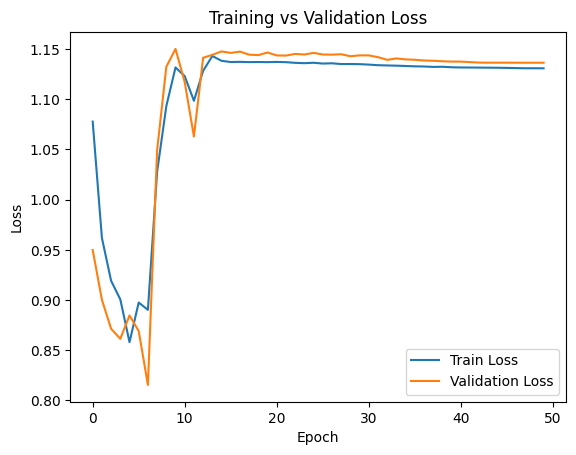

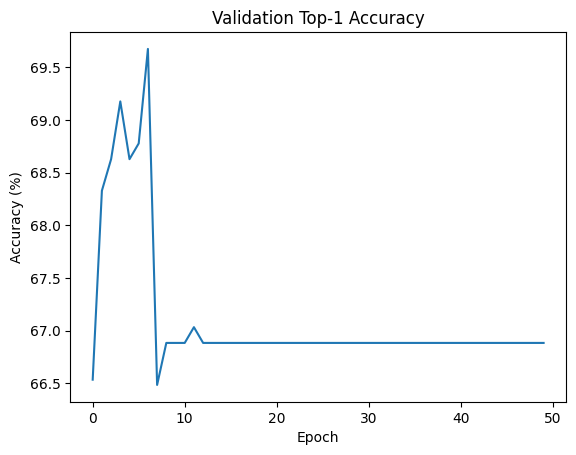

In [11]:
"""
Block 6: Visualize Training Metrics (Extension 3)
Plot training loss, validation loss, and Top-1 accuracy.
"""

import os
import json
import matplotlib.pyplot as plt

log_file = os.path.join(CHECKPOINT_DIR, "log.txt")

epochs = []
train_loss = []
val_loss = []
val_top1 = []

with open(log_file, "r") as f:
    for line in f:
        data = json.loads(line)

        epochs.append(data["epoch"])
        train_loss.append(data["train_loss"])
        val_loss.append(data["test_loss"])
        val_top1.append(data["test_acc1"])

# ----- Loss Curve -----
plt.figure()
plt.plot(epochs, train_loss)
plt.plot(epochs, val_loss)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend(["Train Loss", "Validation Loss"])

plt.show()

# ----- Accuracy Curve -----
plt.figure()
plt.plot(epochs, val_top1)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Validation Top-1 Accuracy")

plt.show()